## Problem Statement

Agricultural performance can change from one season to another because of environmental conditions, farming practices, availability of resources and market conditions.

The raw dataset contains many different agricultural details, so it is not easy to directly understand how performance changes between seasons.

In this project, I will analyze the data and compare Kharif, Rabi and Zaid seasons to find differences in yield, production, resource usage, environmental conditions and economic performance.


In [1]:
# Importing the libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import f_oneway

pd.set_option('display.max_columns', None)


In [2]:
# Reading the dataset

df = pd.read_csv("seasonal_agriculture_performance_dataset.csv")

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])


Number of rows: 4000
Number of columns: 28


In [3]:
# Looking at the first five rows

df.head()


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [4]:
# Checking the structure of the data

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [5]:
# Checking all column names

print(df.columns.tolist())


['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


In [6]:
# Checking the basic statistics

df.describe().round(2)


,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.00,3952.00,4000.00,4000.00,4000.00,4000.00,3960.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,3968.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00
mean,7.89,601.15,26.82,63.21,7.32,6.70,26.51,120.25,57.78,104.76,186.04,5.07,0.83,5.27,43.25,44714.17,526303.58,637860.05,111556.46,6045.57,5.39,46.37
std,4.22,288.93,3.82,11.96,1.12,0.64,6.71,31.22,17.02,27.74,60.26,1.98,0.10,13.36,126.88,30266.16,294419.14,636974.71,545081.89,5572.94,8.84,12.42
min,0.50,80.00,16.20,25.00,3.50,5.20,8.00,40.00,15.00,30.00,40.00,0.50,0.65,0.30,0.15,2594.00,26826.00,6107.00,-1019223.00,128.00,0.14,5.00
25%,4.26,370.20,23.90,54.78,6.60,6.26,21.70,98.50,46.20,86.20,143.98,3.69,0.74,1.05,5.02,21429.25,274577.50,207517.25,-148731.75,2268.75,1.66,37.30
50%,7.90,582.00,26.90,63.00,7.30,6.69,26.40,120.10,57.50,105.10,186.25,5.12,0.83,1.74,11.77,25913.00,519082.50,456830.50,3673.00,4435.00,2.94,46.40
75%,11.65,834.95,29.60,71.90,8.10,7.14,31.30,141.22,69.40,123.60,227.20,6.40,0.91,2.84,24.36,68279.00,761996.50,836874.75,216187.75,7829.75,5.15,54.90
max,15.00,1395.20,39.70,95.00,11.00,8.40,47.00,220.00,120.00,200.00,400.00,12.08,1.00,101.44,1424.40,131240.00,1349990.00,5080900.00,4345421.00,40902.00,79.80,88.90


In [7]:
# Checking important categories

print("Seasons:", df['Season'].unique())
print("Number of crops:", df['Crop'].nunique())
print("Number of states:", df['State'].nunique())
print("Irrigation methods:", df['Irrigation_Method'].unique())


Seasons: ['Kharif' 'Rabi' 'Zaid']
Number of crops: 8
Number of states: 8
Irrigation methods: ['Drip' 'Flood' 'Rainfed' 'Sprinkler']


## Data Cleaning

Before starting the analysis, I checked missing values and duplicate rows. There are a few missing values in rainfall, soil moisture and yield. I will fill numerical missing values using the median of the respective column. There are no duplicate rows in the dataset.


In [8]:
# Checking missing values

missing = df.isnull().sum()
missing[missing > 0]


Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64

In [9]:
# Checking duplicate rows

print("Duplicate rows:", df.duplicated().sum())


Duplicate rows: 0


In [10]:
# Making a copy for cleaning

data = df.copy()

# Filling missing numerical values with the median
numeric_columns = data.select_dtypes(include=np.number).columns

for col in numeric_columns:
    data[col] = data[col].fillna(data[col].median())

# Filling missing text values with the mode
text_columns = data.select_dtypes(include='object').columns

for col in text_columns:
    data[col] = data[col].fillna(data[col].mode()[0])

print("Missing values after cleaning:", data.isnull().sum().sum())


Missing values after cleaning: 0


In [11]:
# Checking the cleaned data

data.head()


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


## Creating Profit Margin

Profit margin is calculated to compare profit with revenue.


In [12]:
# Calculating profit margin

data['Profit_Margin_pct'] = (data['Profit_INR'] / data['Revenue_INR']) * 100

data[['Revenue_INR', 'Profit_INR', 'Profit_Margin_pct']].head()


,Revenue_INR,Profit_INR,Profit_Margin_pct
0,30810,-11852,-38.468030
1,40401,-451950,-1118.660429
2,190466,-124744,-65.494104
3,200740,-95704,-47.675600
4,193607,-144352,-74.559288


# 1. Seasonal Performance

First, I compare the main performance measures for Kharif, Rabi and Zaid seasons.


Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64


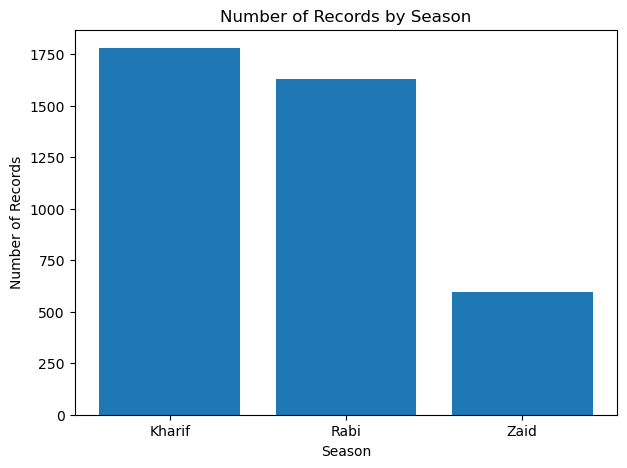

In [13]:
# Number of records in each season

season_count = data['Season'].value_counts()

print(season_count)

plt.figure(figsize=(7, 5))
plt.bar(season_count.index, season_count.values)
plt.title("Number of Records by Season")
plt.xlabel("Season")
plt.ylabel("Number of Records")
plt.show()


In [14]:
# Average agricultural performance by season

season_summary = data.groupby('Season').agg({
    'Yield_Tonnes_Ha': 'mean',
    'Production_Tonnes': 'mean',
    'Revenue_INR': 'mean',
    'Total_Cost_INR': 'mean',
    'Profit_INR': 'mean'
})

season_summary.round(2)


,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Total_Cost_INR,Profit_INR
Season,,,,,
Kharif,5.63,46.31,710719.06,531804.41,178914.65
Rabi,5.04,41.49,601526.05,513836.58,87689.47
Zaid,4.64,38.89,519171.90,543976.73,-24804.82


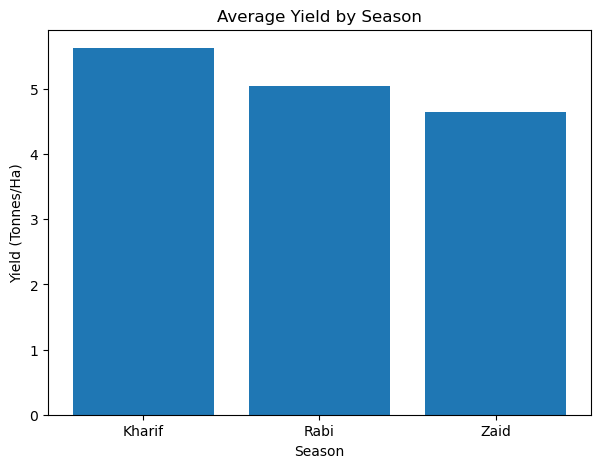

Highest average yield: Kharif
Lowest average yield: Zaid


In [15]:
# Average yield by season

yield_by_season = data.groupby('Season')['Yield_Tonnes_Ha'].mean()

plt.figure(figsize=(7, 5))
plt.bar(yield_by_season.index, yield_by_season.values)
plt.title("Average Yield by Season")
plt.xlabel("Season")
plt.ylabel("Yield (Tonnes/Ha)")
plt.show()

print("Highest average yield:", yield_by_season.idxmax())
print("Lowest average yield:", yield_by_season.idxmin())


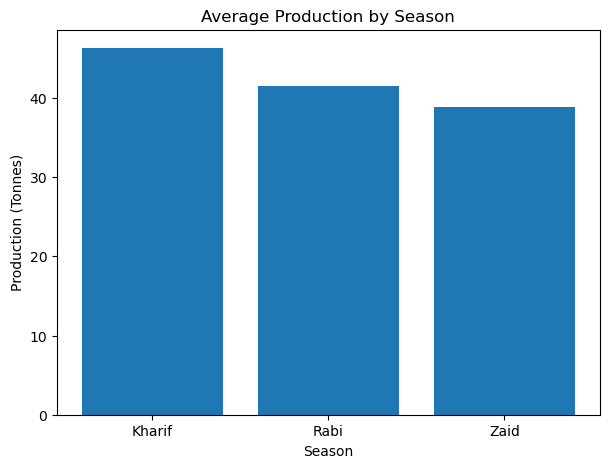

Highest average production: Kharif
Lowest average production: Zaid


In [16]:
# Average production by season

production_by_season = data.groupby('Season')['Production_Tonnes'].mean()

plt.figure(figsize=(7, 5))
plt.bar(production_by_season.index, production_by_season.values)
plt.title("Average Production by Season")
plt.xlabel("Season")
plt.ylabel("Production (Tonnes)")
plt.show()

print("Highest average production:", production_by_season.idxmax())
print("Lowest average production:", production_by_season.idxmin())


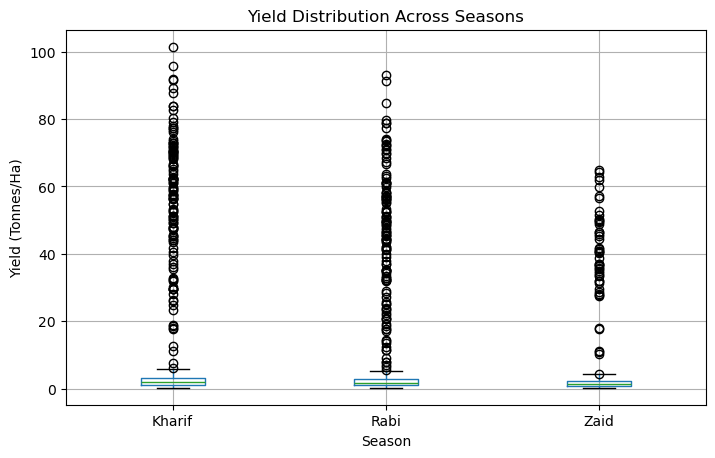

In [17]:
# Distribution of yield in each season

data.boxplot(column='Yield_Tonnes_Ha', by='Season', figsize=(8, 5))
plt.title("Yield Distribution Across Seasons")
plt.suptitle("")
plt.xlabel("Season")
plt.ylabel("Yield (Tonnes/Ha)")
plt.show()


### Observation

The seasonal tables and graphs show the difference in average yield and production. The printed highest and lowest seasons give a direct answer based on the dataset.


# 2. Environmental Conditions

Seasonal weather and soil conditions can affect farming results. I compare rainfall, temperature, humidity, sunlight and soil moisture.


In [18]:
# Average environmental conditions by season

environment = data.groupby('Season').agg({
    'Rainfall_mm': 'mean',
    'Avg_Temperature_C': 'mean',
    'Humidity_pct': 'mean',
    'Sunlight_Hours_Day': 'mean',
    'Soil_Moisture_pct': 'mean'
})

environment.round(2)


,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_Moisture_pct
Season,,,,,
Kharif,849.20,28.45,71.81,6.79,31.15
Rabi,437.62,23.49,57.89,7.59,24.07
Zaid,304.65,31.04,52.01,8.18,19.28


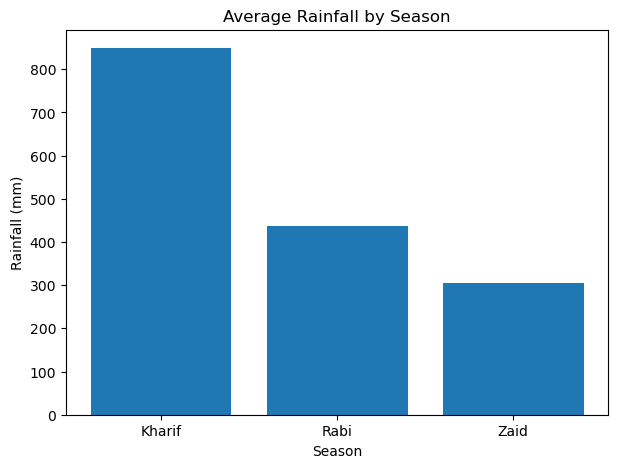

In [19]:
# Rainfall by season

rainfall = data.groupby('Season')['Rainfall_mm'].mean()

plt.figure(figsize=(7, 5))
plt.bar(rainfall.index, rainfall.values)
plt.title("Average Rainfall by Season")
plt.xlabel("Season")
plt.ylabel("Rainfall (mm)")
plt.show()


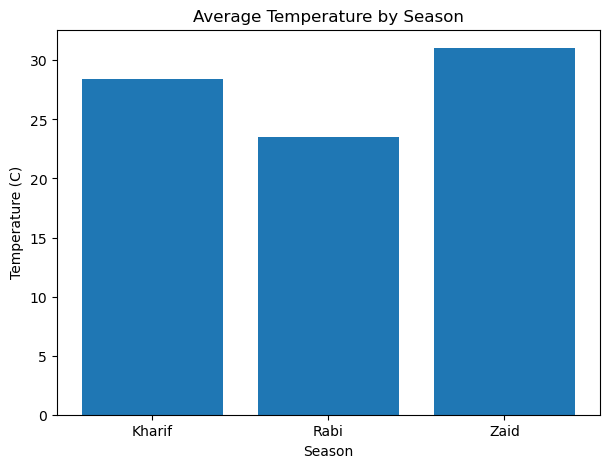

In [20]:
# Temperature by season

temperature = data.groupby('Season')['Avg_Temperature_C'].mean()

plt.figure(figsize=(7, 5))
plt.bar(temperature.index, temperature.values)
plt.title("Average Temperature by Season")
plt.xlabel("Season")
plt.ylabel("Temperature (C)")
plt.show()


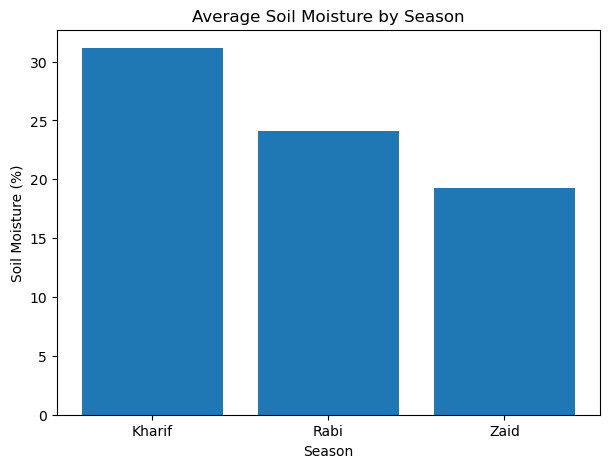

In [21]:
# Soil moisture by season

soil_moisture = data.groupby('Season')['Soil_Moisture_pct'].mean()

plt.figure(figsize=(7, 5))
plt.bar(soil_moisture.index, soil_moisture.values)
plt.title("Average Soil Moisture by Season")
plt.xlabel("Season")
plt.ylabel("Soil Moisture (%)")
plt.show()


In [22]:
# Simple environmental observation

print("Highest rainfall season:", rainfall.idxmax())
print("Highest temperature season:", temperature.idxmax())
print("Highest soil moisture season:", soil_moisture.idxmax())


Highest rainfall season: Kharif
Highest temperature season: Zaid
Highest soil moisture season: Kharif


### Observation

The environmental results show clear seasonal differences. These changes are useful when comparing them with yield and resource usage.


# 3. Resource Usage

I compare fertilizer, nutrients, pesticide and water use across seasons.


In [23]:
# Average resource usage by season

resources = data.groupby('Season').agg({
    'Nitrogen_kg_ha': 'mean',
    'Phosphorus_kg_ha': 'mean',
    'Potassium_kg_ha': 'mean',
    'Fertilizer_kg_ha': 'mean',
    'Pesticide_Litre_ha': 'mean',
    'Water_Used_m3': 'mean'
})

resources.round(2)


,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Water_Used_m3
Season,,,,,,
Kharif,120.02,58.10,105.30,187.08,5.08,6102.20
Rabi,120.40,57.31,103.93,185.41,5.02,5846.99
Zaid,120.53,58.13,105.42,184.64,5.17,6419.89


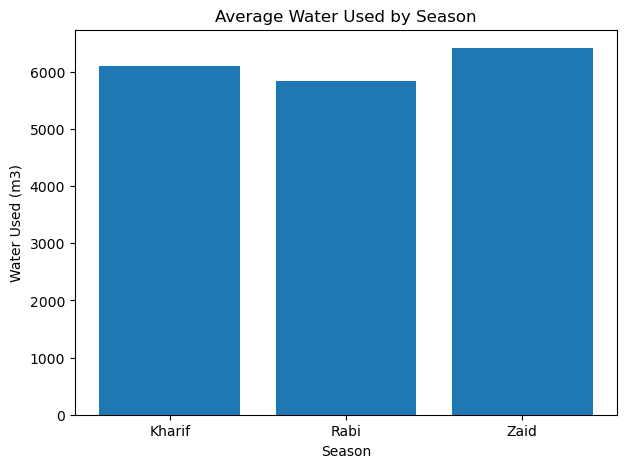

Highest water use: Zaid
Lowest water use: Rabi


In [24]:
# Water used by season

water = data.groupby('Season')['Water_Used_m3'].mean()

plt.figure(figsize=(7, 5))
plt.bar(water.index, water.values)
plt.title("Average Water Used by Season")
plt.xlabel("Season")
plt.ylabel("Water Used (m3)")
plt.show()

print("Highest water use:", water.idxmax())
print("Lowest water use:", water.idxmin())


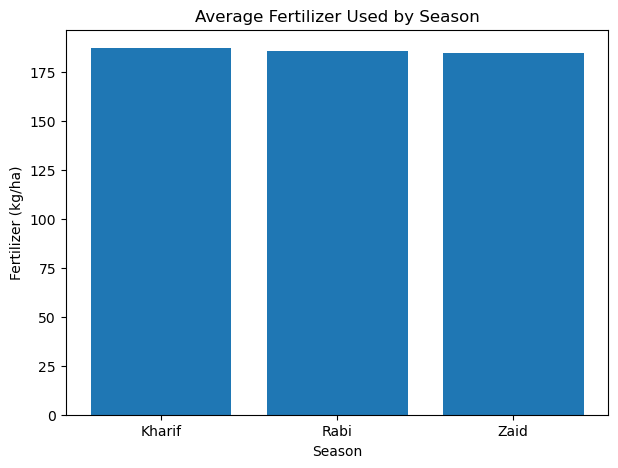

In [25]:
# Fertilizer used by season

fertilizer = data.groupby('Season')['Fertilizer_kg_ha'].mean()

plt.figure(figsize=(7, 5))
plt.bar(fertilizer.index, fertilizer.values)
plt.title("Average Fertilizer Used by Season")
plt.xlabel("Season")
plt.ylabel("Fertilizer (kg/ha)")
plt.show()


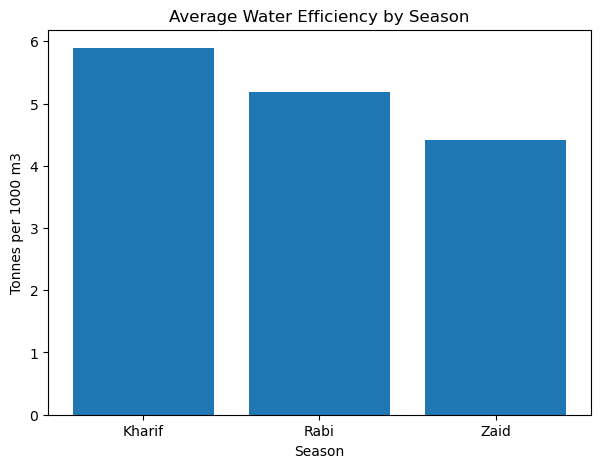

Best water efficiency: Kharif


In [26]:
# Water efficiency by season

water_efficiency = data.groupby('Season')['Water_Efficiency_t_per_1000m3'].mean()

plt.figure(figsize=(7, 5))
plt.bar(water_efficiency.index, water_efficiency.values)
plt.title("Average Water Efficiency by Season")
plt.xlabel("Season")
plt.ylabel("Tonnes per 1000 m3")
plt.show()

print("Best water efficiency:", water_efficiency.idxmax())


### Observation

Resource use is compared season by season. Water efficiency is also included because a season may use more water but still have better or lower output per unit of water.


# 4. Irrigation Methods

I check whether the use of irrigation methods changes between seasons.


In [27]:
# Number of farms using each irrigation method in each season

irrigation = pd.crosstab(data['Season'], data['Irrigation_Method'])
irrigation


Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,405,590,463,321
Rabi,370,526,438,293
Zaid,140,194,140,120


In [28]:
# Percentage of irrigation methods in each season

irrigation_percent = pd.crosstab(
    data['Season'],
    data['Irrigation_Method'],
    normalize='index'
) * 100

irrigation_percent.round(2)


Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,22.77,33.16,26.03,18.04
Rabi,22.74,32.33,26.92,18.01
Zaid,23.57,32.66,23.57,20.20


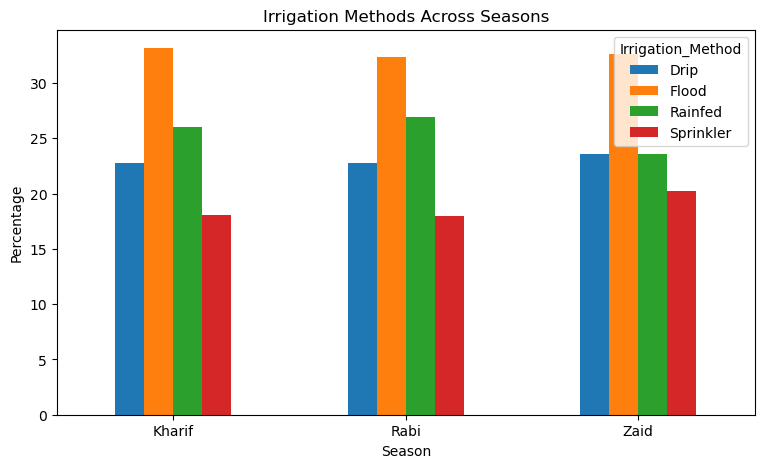

In [29]:
# Irrigation method graph

irrigation_percent.plot(kind='bar', figsize=(9, 5))
plt.title("Irrigation Methods Across Seasons")
plt.xlabel("Season")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.show()


In [30]:
# Most common irrigation method in each season

print(irrigation.idxmax(axis=1))


Season
Kharif    Flood
Rabi      Flood
Zaid      Flood
dtype: object


### Observation

The irrigation table shows which methods are more common in each season. This helps compare agricultural activities and water management practices.


# 5. Economic Performance

I compare market price, total cost, revenue, profit and profit margin across seasons.


In [31]:
# Economic performance by season

economic = data.groupby('Season').agg({
    'Market_Price_INR_Tonne': 'mean',
    'Total_Cost_INR': 'mean',
    'Revenue_INR': 'mean',
    'Profit_INR': 'mean',
    'Profit_Margin_pct': 'mean'
})

economic.round(2)


,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Profit_Margin_pct
Season,,,,,
Kharif,44850.91,531804.41,710719.06,178914.65,-38.64
Rabi,44747.97,513836.58,601526.05,87689.47,-44.27
Zaid,44212.03,543976.73,519171.90,-24804.82,-69.35


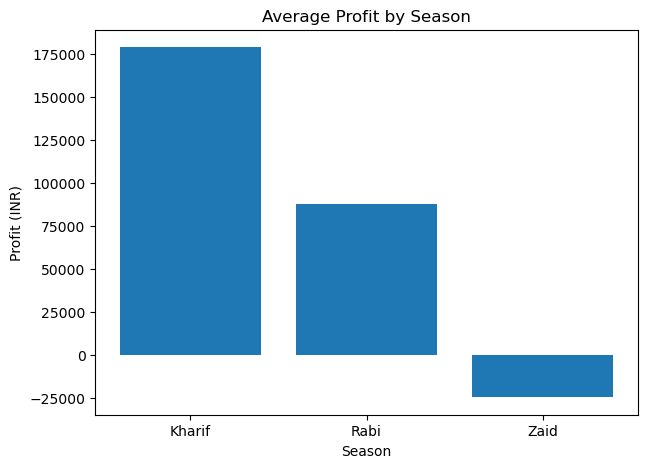

Highest average profit: Kharif
Lowest average profit: Zaid


In [32]:
# Average profit by season

profit_by_season = data.groupby('Season')['Profit_INR'].mean()

plt.figure(figsize=(7, 5))
plt.bar(profit_by_season.index, profit_by_season.values)
plt.title("Average Profit by Season")
plt.xlabel("Season")
plt.ylabel("Profit (INR)")
plt.show()

print("Highest average profit:", profit_by_season.idxmax())
print("Lowest average profit:", profit_by_season.idxmin())


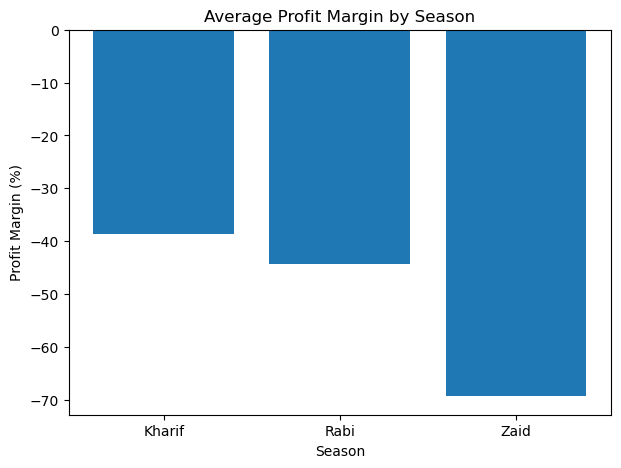

Highest profit margin: Kharif


In [33]:
# Average profit margin by season

margin_by_season = data.groupby('Season')['Profit_Margin_pct'].mean()

plt.figure(figsize=(7, 5))
plt.bar(margin_by_season.index, margin_by_season.values)
plt.title("Average Profit Margin by Season")
plt.xlabel("Season")
plt.ylabel("Profit Margin (%)")
plt.show()

print("Highest profit margin:", margin_by_season.idxmax())


### Observation

The economic comparison shows how revenue, cost and profit change between seasons. Profit margin gives another way to compare the financial performance.


# 6. Crop and Season Comparison

A season may not perform equally for every crop. Therefore, I compare crop yield across seasons.


In [34]:
# Average yield for each crop and season

crop_season_yield = data.groupby(
    ['Crop', 'Season']
)['Yield_Tonnes_Ha'].mean().unstack()

crop_season_yield.round(2)


Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.73,1.47,1.20
Cotton,1.37,1.20,0.96
Groundnut,1.48,1.23,1.04
Maize,2.97,2.60,2.29
Pulses,1.04,0.88,0.67
Rice,2.70,2.32,1.90
Sugarcane,53.46,43.29,38.42
Wheat,2.25,2.06,1.75


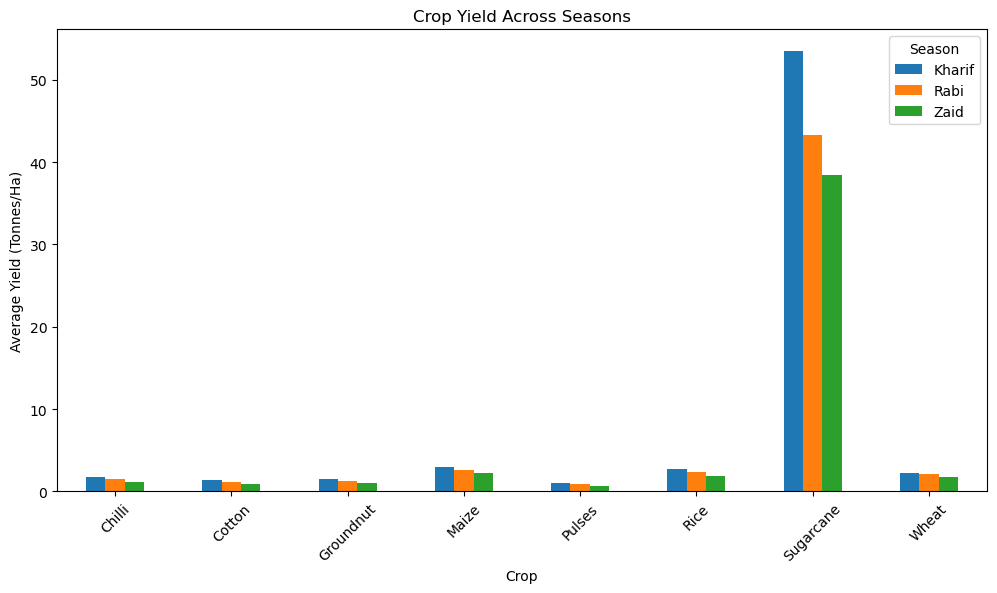

In [35]:
# Crop yield graph

crop_season_yield.plot(kind='bar', figsize=(12, 6))
plt.title("Crop Yield Across Seasons")
plt.xlabel("Crop")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=45)
plt.show()


In [36]:
# Best crop and season combination for yield

best_crop_season = data.groupby(
    ['Crop', 'Season']
)['Yield_Tonnes_Ha'].mean().sort_values(ascending=False)

print("Best crop-season combination:")
print(best_crop_season.head(1))

print("\nLowest crop-season combination:")
print(best_crop_season.tail(1))


Best crop-season combination:
Crop       Season
Sugarcane  Kharif    53.45912
Name: Yield_Tonnes_Ha, dtype: float64

Lowest crop-season combination:
Crop    Season
Pulses  Zaid      0.669677
Name: Yield_Tonnes_Ha, dtype: float64


In [37]:
# Number of crops for which each season gives the highest average yield

best_season_for_crop = crop_season_yield.idxmax(axis=1)
print(best_season_for_crop.value_counts())


Kharif    8
Name: count, dtype: int64


### Observation

The crop-season comparison shows that seasonal performance can be different for different crops. This is useful for deciding which crops perform better under particular seasonal conditions.


# 7. State and Season Comparison

I compare average profit across states and seasons to check whether the seasonal pattern is similar in different regions.


In [38]:
# Average profit by state and season

state_season_profit = data.groupby(
    ['State', 'Season']
)['Profit_INR'].mean().unstack()

state_season_profit.round(2)


Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,169315.52,26315.71,-84084.87
Gujarat,217051.33,82846.20,-106929.61
Karnataka,201226.21,70952.61,23310.91
Madhya Pradesh,134242.40,61576.26,209.70
Maharashtra,168801.05,159581.50,-40597.60
Punjab,133779.10,169294.52,62109.69
Tamil Nadu,211303.96,70456.86,-15175.20
Telangana,199668.38,62824.60,-34620.78


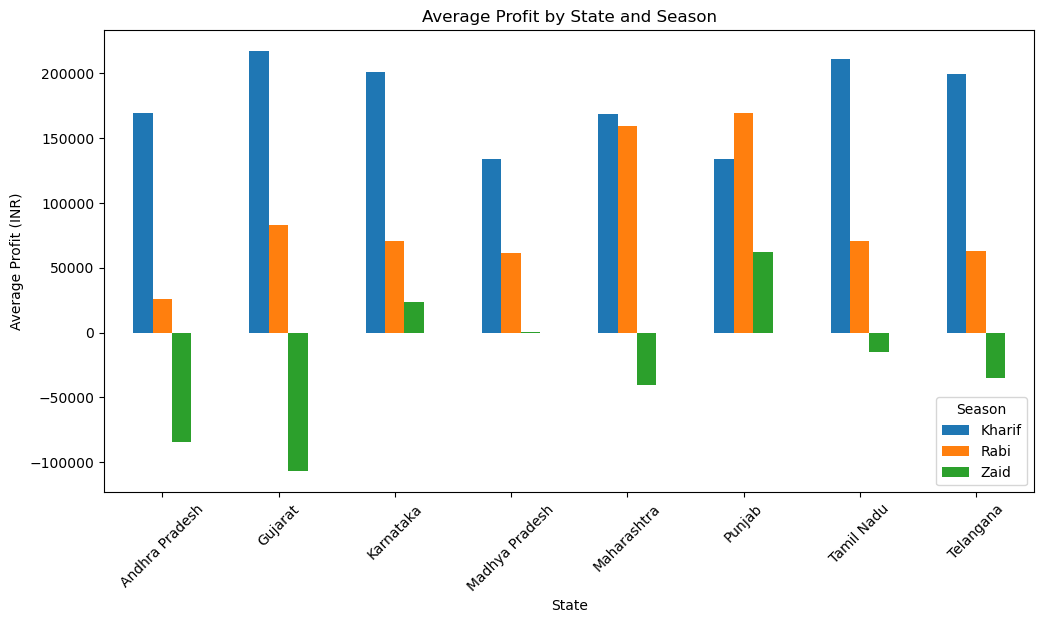

In [39]:
# State-season profit graph

state_season_profit.plot(kind='bar', figsize=(12, 6))
plt.title("Average Profit by State and Season")
plt.xlabel("State")
plt.ylabel("Average Profit (INR)")
plt.xticks(rotation=45)
plt.show()


In [40]:
# Best state and season combination for profit

best_state_season = data.groupby(
    ['State', 'Season']
)['Profit_INR'].mean().sort_values(ascending=False)

print("Best state-season combination:")
print(best_state_season.head(1))

print("\nLowest state-season combination:")
print(best_state_season.tail(1))


Best state-season combination:
State    Season
Gujarat  Kharif    217051.330317
Name: Profit_INR, dtype: float64

Lowest state-season combination:
State    Season
Gujarat  Zaid     -106929.61194
Name: Profit_INR, dtype: float64


In [41]:
# Which season gives the highest profit in each state?

best_season_by_state = state_season_profit.idxmax(axis=1)

print(best_season_by_state.value_counts())


Kharif    7
Rabi      1
Name: count, dtype: int64


### Observation

The state comparison checks whether one season performs best in most states or whether different states have different seasonal results.


# 8. Correlation Analysis

Correlation is used to check the relationship between important environmental, resource and agricultural variables.

A positive value means the variables tend to increase together, while a negative value means they tend to move in opposite directions.


In [42]:
# Selecting variables for correlation

correlation_columns = [
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Humidity_pct',
    'Sunlight_Hours_Day',
    'Soil_Moisture_pct',
    'Fertilizer_kg_ha',
    'Pesticide_Litre_ha',
    'Water_Used_m3',
    'Yield_Tonnes_Ha',
    'Production_Tonnes',
    'Revenue_INR',
    'Profit_INR'
]

correlation = data[correlation_columns].corr()

correlation.round(2)


,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_Moisture_pct,Fertilizer_kg_ha,Pesticide_Litre_ha,Water_Used_m3,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Profit_INR
Rainfall_mm,1.00,0.20,0.52,-0.36,0.51,0.02,0.00,0.00,0.03,0.02,0.10,0.11
Avg_Temperature_C,0.20,1.00,0.14,-0.03,0.08,0.02,0.01,0.02,0.01,0.01,0.03,0.01
Humidity_pct,0.52,0.14,1.00,-0.30,0.45,0.02,-0.00,-0.00,0.01,0.00,0.06,0.06
Sunlight_Hours_Day,-0.36,-0.03,-0.30,1.00,-0.30,-0.01,-0.02,-0.01,-0.02,-0.02,-0.05,-0.05
Soil_Moisture_pct,0.51,0.08,0.45,-0.30,1.00,0.01,-0.02,0.00,0.01,0.00,0.08,0.09
Fertilizer_kg_ha,0.02,0.02,0.02,-0.01,0.01,1.00,-0.00,0.00,0.00,0.00,0.01,-0.07
Pesticide_Litre_ha,0.00,0.01,-0.00,-0.02,-0.02,-0.00,1.00,0.00,-0.01,-0.01,-0.00,-0.03
Water_Used_m3,0.00,0.02,-0.00,-0.01,0.00,0.00,0.00,1.00,0.39,0.52,0.43,0.19
Yield_Tonnes_Ha,0.03,0.01,0.01,-0.02,0.01,0.00,-0.01,0.39,1.00,0.88,0.43,0.49
Production_Tonnes,0.02,0.01,0.00,-0.02,0.00,0.00,-0.01,0.52,0.88,1.00,0.56,0.55


In [43]:
# Correlation with yield

yield_correlation = correlation['Yield_Tonnes_Ha'].sort_values(ascending=False)
yield_correlation


Yield_Tonnes_Ha       1.000000
Production_Tonnes     0.882813
Profit_INR            0.488466
Revenue_INR           0.432152
Water_Used_m3         0.386294
Rainfall_mm           0.030951
Humidity_pct          0.012297
Soil_Moisture_pct     0.010999
Avg_Temperature_C     0.009996
Fertilizer_kg_ha      0.000018
Pesticide_Litre_ha   -0.007779
Sunlight_Hours_Day   -0.015341
Name: Yield_Tonnes_Ha, dtype: float64

In [44]:
# Correlation with profit

profit_correlation = correlation['Profit_INR'].sort_values(ascending=False)
profit_correlation


Profit_INR            1.000000
Revenue_INR           0.887331
Production_Tonnes     0.554172
Yield_Tonnes_Ha       0.488466
Water_Used_m3         0.190278
Rainfall_mm           0.107648
Soil_Moisture_pct     0.091281
Humidity_pct          0.063775
Avg_Temperature_C     0.009043
Pesticide_Litre_ha   -0.025705
Sunlight_Hours_Day   -0.054822
Fertilizer_kg_ha     -0.073542
Name: Profit_INR, dtype: float64

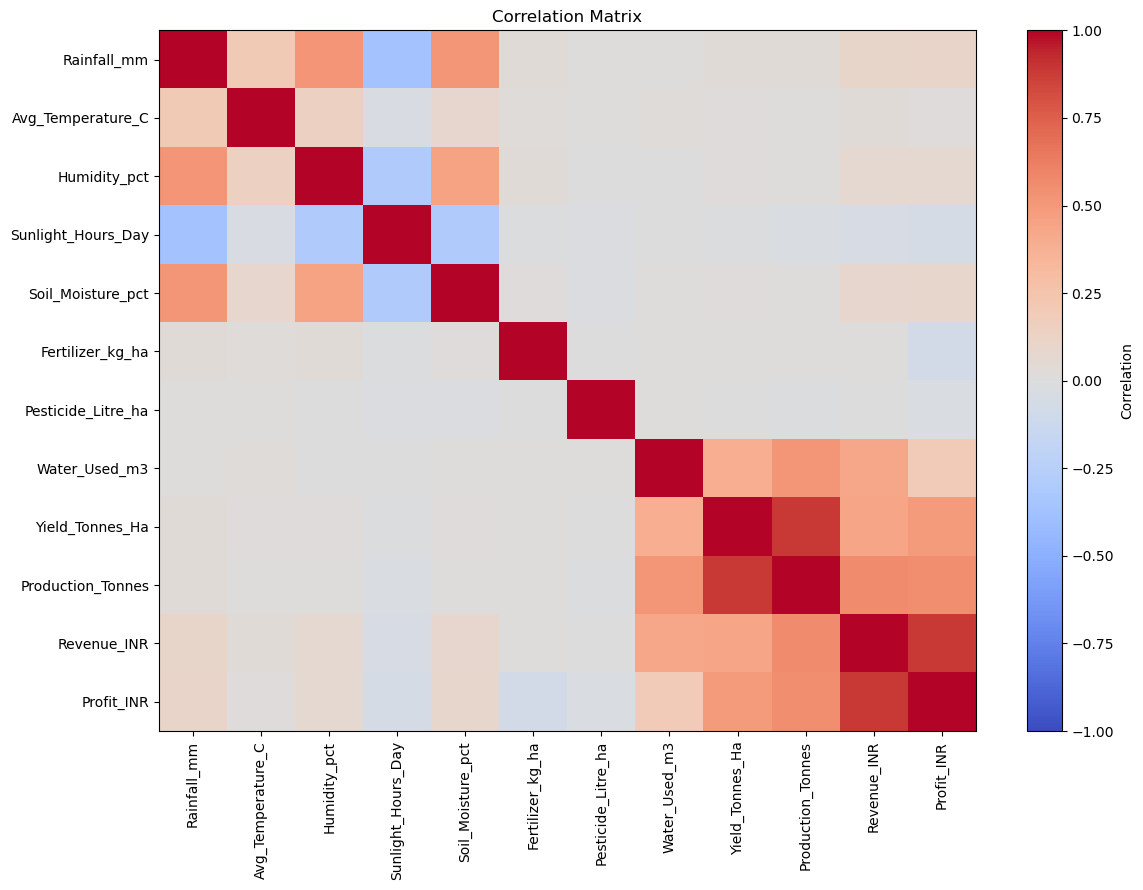

In [45]:
# Correlation matrix

plt.figure(figsize=(12, 9))
plt.imshow(correlation, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=90)
plt.yticks(range(len(correlation.index)), correlation.index)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


### Observation

The correlation values show which variables have stronger positive or negative relationships with yield and profit. Correlation shows association, not proof that one variable causes another.


# 9. Statistical Test

I use one-way ANOVA to check whether the average yield and profit are significantly different across the three seasons.

**Null hypothesis:** The average values are the same across seasons.

**Alternative hypothesis:** At least one season has a different average.

The significance level used is 0.05.


In [46]:
# ANOVA test for yield

seasons = data['Season'].unique()

yield_groups = [
    data[data['Season'] == season]['Yield_Tonnes_Ha']
    for season in seasons
]

yield_anova = f_oneway(*yield_groups)

print("F-statistic:", round(yield_anova.statistic, 4))
print("p-value:", round(yield_anova.pvalue, 6))

if yield_anova.pvalue < 0.05:
    print("Result: The average yield is significantly different across seasons.")
else:
    print("Result: The average yield is not significantly different across seasons.")


F-statistic: 1.5439
p-value: 0.213678
Result: The average yield is not significantly different across seasons.


In [47]:
# ANOVA test for profit

profit_groups = [
    data[data['Season'] == season]['Profit_INR']
    for season in seasons
]

profit_anova = f_oneway(*profit_groups)

print("F-statistic:", round(profit_anova.statistic, 4))
print("p-value:", round(profit_anova.pvalue, 6))

if profit_anova.pvalue < 0.05:
    print("Result: The average profit is significantly different across seasons.")
else:
    print("Result: The average profit is not significantly different across seasons.")


F-statistic: 34.2918
p-value: 0.0
Result: The average profit is significantly different across seasons.


# 10. Unusual Seasonal Patterns

I use the IQR method separately for each season to find unusual yield values. Doing this separately helps compare unusual observations within each season.


In [48]:
# Finding unusual yield values season by season

outlier_summary = []

for season in data['Season'].unique():
    season_data = data[data['Season'] == season]

    q1 = season_data['Yield_Tonnes_Ha'].quantile(0.25)
    q3 = season_data['Yield_Tonnes_Ha'].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    count = ((season_data['Yield_Tonnes_Ha'] < lower) |
             (season_data['Yield_Tonnes_Ha'] > upper)).sum()

    outlier_summary.append([season, lower, upper, count])

outlier_table = pd.DataFrame(
    outlier_summary,
    columns=['Season', 'Lower_Limit', 'Upper_Limit', 'Unusual_Yield_Records']
)

outlier_table.round(2)


,Season,Lower_Limit,Upper_Limit,Unusual_Yield_Records
0,Kharif,-1.70,5.98,121
1,Rabi,-1.55,5.31,125
2,Zaid,-1.27,4.41,50


In [49]:
# Highest and lowest yield observations

print("Highest yield record:")
print(data.loc[data['Yield_Tonnes_Ha'].idxmax(),
               ['Farm_ID', 'State', 'Crop', 'Season', 'Yield_Tonnes_Ha']])

print("\nLowest yield record:")
print(data.loc[data['Yield_Tonnes_Ha'].idxmin(),
               ['Farm_ID', 'State', 'Crop', 'Season', 'Yield_Tonnes_Ha']])


Highest yield record:
Farm_ID              SF11716
State                Gujarat
Crop               Sugarcane
Season                Kharif
Yield_Tonnes_Ha       101.44
Name: 1715, dtype: object

Lowest yield record:
Farm_ID                SF10002
State              Maharashtra
Crop                     Maize
Season                  Kharif
Yield_Tonnes_Ha            0.3
Name: 1, dtype: object


### Observation

The outlier table shows whether unusual yield values are concentrated more in one season. These records can be checked separately because an unusually high or low value may affect the average.


# 11. Direct Answers to the Project Questions

The following cells summarize the main results directly from the dataset.


In [50]:
# Answer 1 and 2: seasonal performance and major patterns

print("1. Highest average yield season:", yield_by_season.idxmax())
print("   Average yield:", round(yield_by_season.max(), 2), "tonnes/ha")

print("\n2. Lowest average yield season:", yield_by_season.idxmin())
print("   Average yield:", round(yield_by_season.min(), 2), "tonnes/ha")

print("\nHighest average profit season:", profit_by_season.idxmax())
print("Lowest average profit season:", profit_by_season.idxmin())


1. Highest average yield season: Kharif
   Average yield: 5.63 tonnes/ha

2. Lowest average yield season: Zaid
   Average yield: 4.64 tonnes/ha

Highest average profit season: Kharif
Lowest average profit season: Zaid


In [51]:
# Answer 3 and 4: changing characteristics and agricultural activities

print("3. Environmental conditions:")
print("   Highest rainfall:", rainfall.idxmax())
print("   Highest temperature:", temperature.idxmax())
print("   Highest soil moisture:", soil_moisture.idxmax())

print("\n4. Most common irrigation method in each season:")
print(irrigation.idxmax(axis=1))


3. Environmental conditions:
   Highest rainfall: Kharif
   Highest temperature: Zaid
   Highest soil moisture: Kharif

4. Most common irrigation method in each season:
Season
Kharif    Flood
Rabi      Flood
Zaid      Flood
dtype: object


In [52]:
# Answer 5 and 6: resource usage and environmental relationships

print("5. Highest water use season:", water.idxmax())
print("   Highest fertilizer use season:", fertilizer.idxmax())

print("\n6. Correlation with yield:")
print(yield_correlation.sort_values(ascending=False).head(5))


5. Highest water use season: Zaid
   Highest fertilizer use season: Kharif

6. Correlation with yield:
Yield_Tonnes_Ha      1.000000
Production_Tonnes    0.882813
Profit_INR           0.488466
Revenue_INR          0.432152
Water_Used_m3        0.386294
Name: Yield_Tonnes_Ha, dtype: float64


In [53]:
# Answer 7 and 8: economic outcomes and consistency across groups

print("7. Highest profit season:", profit_by_season.idxmax())
print("   Highest profit margin season:", margin_by_season.idxmax())

print("\n8. Best season for crop yield:")
print(best_season_for_crop.value_counts())

print("\nBest season for state profit:")
print(best_season_by_state.value_counts())


7. Highest profit season: Kharif
   Highest profit margin season: Kharif

8. Best season for crop yield:
Kharif    8
Name: count, dtype: int64

Best season for state profit:
Kharif    7
Rabi      1
Name: count, dtype: int64


In [54]:
# Answer 9 and 10: unusual patterns and important insights

print("9. Unusual yield records by season:")
print(outlier_table[['Season', 'Unusual_Yield_Records']])

print("\n10. Best crop-season combination:")
print(best_crop_season.head(1))

print("\nBest state-season combination:")
print(best_state_season.head(1))


9. Unusual yield records by season:
   Season  Unusual_Yield_Records
0  Kharif                    121
1    Rabi                    125
2    Zaid                     50

10. Best crop-season combination:
Crop       Season
Sugarcane  Kharif    53.45912
Name: Yield_Tonnes_Ha, dtype: float64

Best state-season combination:
State    Season
Gujarat  Kharif    217051.330317
Name: Profit_INR, dtype: float64


In [55]:
# Answer 11 and 12: conclusion and planning support

print("11. Main conclusion:")
print("Seasonal conditions are associated with differences in agricultural performance.")
print("The actual differences can be seen in the yield, resource, environmental and economic comparisons.")

print("\n12. Planning support:")
print("Season-wise yield, resource use and profit can be considered while planning crops,")
print("irrigation and other agricultural activities.")


11. Main conclusion:
Seasonal conditions are associated with differences in agricultural performance.
The actual differences can be seen in the yield, resource, environmental and economic comparisons.

12. Planning support:
Season-wise yield, resource use and profit can be considered while planning crops,
irrigation and other agricultural activities.


# 12. Main Findings


- Kharif, Rabi and Zaid show different average agricultural performance.
- Environmental conditions such as rainfall, temperature and soil moisture change between seasons.
- Water and other resource usage also changes across seasons.
- Crop performance is not the same for every season.
- Profit and profit margin differ between seasons.
- State-wise results show that seasonal performance can also vary by region.
- Correlation analysis helps identify variables that have stronger relationships with yield and profit.
- ANOVA gives a statistical check for seasonal differences.
- IQR analysis helps identify unusual yield observations.

The exact highest and lowest values are printed above directly from the dataset.


# 14. Conclusion

In this project, I analyzed the agricultural dataset with a focus on seasonal differences.

The analysis covered data cleaning, seasonal performance, environmental conditions, resource usage, irrigation methods, economic performance, crop and state comparisons, correlation analysis, ANOVA and unusual values.

The results show that agricultural conditions and performance can vary across Kharif, Rabi and Zaid seasons. Comparing these differences can help in making better decisions about crops, water use, resources and seasonal planning.
